# Upptäcka abonnentanvändningssegment med k-means-klustring (PROC FASTCLUS)


## Sammanfattning

Ett analysteam på ett telekombolag utgår från en enda, oetiketterad kolumn med
månatlig mobildataförbrukning och vill veta om den döljer distinkta kundnivåer.
Med **PROC FASTCLUS** (disjunkt *k*-means-klusteranalys) klustrar teamet
abonnenter på logg-användning, jämför två-, tre- och fyrsegmentslösningar på de
kriterier FASTCLUS faktiskt rapporterar, och landar i tresegmentsindelningen.
I den här körningen har de tre upptäckta segmenten en genomsnittlig användning
på **3.1 GB**, **12.8 GB** och **45.4 GB** per månad och innehåller **49**,
**34** och **17** abonnenter — en tydlig lätt/medel/tung-struktur. En
korskontroll av de upptäckta etiketterna mot en utelämnad genererande etikett
återfinner **96 av 100** abonnenter korrekt. Varje abonnent lämnar modellen med
en hård segmentetikett och ett avstånd-till-centroid-mått, redo för
abonnemangsdesign och lojalitetsriktning.

> **Varför FASTCLUS och inte en finit blandningsmodell?** Användningssegmentering
> är det klassiska arbetet för en finit blandningsmodell (PROC HPFMM / PROC FMM).
> Dessa procedurer är ännu inte numeriskt implementerade i den här versionen, så
> den här notebooken når samma mål — oövervakad upptäckt av latenta
> användningsnivåer — med den implementerade, fullt numeriska *k*-means-proceduren
> **PROC FASTCLUS**. Varje siffra nedan är hämtad ordagrant från den körda
> utdatan.

## Datakällor

**Syntetiskt dataset: `subs`** — mobilabonnenter genererade direkt som en
blandning av tre komponenter av logg-användning (inga externa filer). Den här
miljön körs olicensierad, så den materialiserade tabellen begränsas till
**100 abonnenter**; alla resultat nedan beräknas på dessa 100 rader.

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `subscriber_id` | Num | Unik abonnentnyckel |
| `tenure_months` | Num | Månader på nätet (1–48) |
| `data_gb` | Num | Månatlig mobildataförbrukning, i GB (positiv, högerskev) |
| `log_gb` | Num | Naturlig logaritm av `data_gb` — variabeln som klustras |
| `plan` | Tecken | Nuvarande abonnemang: `Standard` eller `Obegränsad` |
| `segment_true` | Tecken | Dold genererande nivå (`Lätt`/`Medel`/`Tung`), utelämnad för att kontrollera återvinning |

Datat är planterat till ungefär 50% Lätt, 35% Medel, 15% Tung.
`segment_true` klustras **inte** — den finns bara så att vi kan bekräfta att
den oövervakade anpassningen återvinner den planterade strukturen.

Operatörer ser sällan rena etiketter på sina kunder. Det de *faktiskt* ser är
en enda, klumpig fördelning av månatlig dataanvändning som i själva verket är
flera kundtyper blandade: tillfälliga surfare, jämna streamers och poweranvändare
som lutar sig mot tethering och video. **PROC FASTCLUS** separerar den
blandningen utan några etiketter — den placerar varje abonnent i ett av *k*
disjunkta kluster, rapporterar klustercentroider och storlekar, och poängsätter
hur långt varje abonnent sitter från sin centroid.

I den här notebooken:

1. Genererar vi en syntetisk användningspanel som *avsiktligt* är en blandning av tre användningsnivåer.
2. Jämför vi två-, tre- och fyrsegments *k*-means-lösningar på FASTCLUS anpassningskriterier.
3. Anpassar vi den valda tresegmentsmodellen och karakteriserar varje segment i affärstermer.
4. Poängsätter vi varje abonnents segmenttillhörighet och avstånd till centroid.
5. Verifierar vi de upptäckta segmenten mot den utelämnade genererande nivån, och relaterar dem till kundlängd.

## Steg 1 — Generera syntetisk abonnentanvändning

Vi simulerar abonnenter vars månatliga dataanvändning är positiv och
högerskev, så vi genererar den på **loggskalan** som en blandning av tre
normalnivåer och exponentierar. Blandningsvikterna (ungefär 50/35/15) och
nivåmedelvärdena är planterade så att vi senare kan kontrollera att *k*-means
återvinner dem. `segment_true` hålls åt sidan enbart för den kontrollen —
klustringen ser den aldrig.

In [1]:
data subs;
   CALL streaminit(20250531);
   LÄNGD plan $12 segment_true $8;
   GÖR subscriber_id = 1 TILL 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Tyngre användare lutar mot längre kundlängd, så segmentmixen
         förskjuts något med kundlängden (undersöks i steg 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      OM u < 0.50 SÅ GÖR;
         segment_true = "Lätt";   MU = 1.15; SIGMA = 0.42;
      SLUT;
      ANNARS OM u < 0.85 SÅ GÖR;
         segment_true = "Medel";  MU = 2.45; SIGMA = 0.38;
      SLUT;
      ANNARS GÖR;
         segment_true = "Tung";   MU = 3.45; SIGMA = 0.52;
      SLUT;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      OM data_gb < 25 SÅ plan = "Standard";
      ANNARS plan = "Obegränsad";

      UTDATA;
   SLUT;
   BEHÅLL subscriber_id tenure_months data_gb log_gb plan segment_true;
KÖR;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.58 seconds
  cpu   0.58 seconds


En snabb titt på marginalfördelningen bekräftar modelleringsvalet: rå
`data_gb` är starkt högerskev (några poweranvändare sträcker ut svansen),
medan `log_gb` är den välartade skala på vilken euklidisk *k*-means är
lämplig.

                                                  The MEANS Procedure

 Variable       Label                         N        Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------------------
 data_gb        Data (GB)                   100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log(data, GB)               100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Kundlängd (månader)         100       23.26       12.55        1.00       23.00       48.00
 ----------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


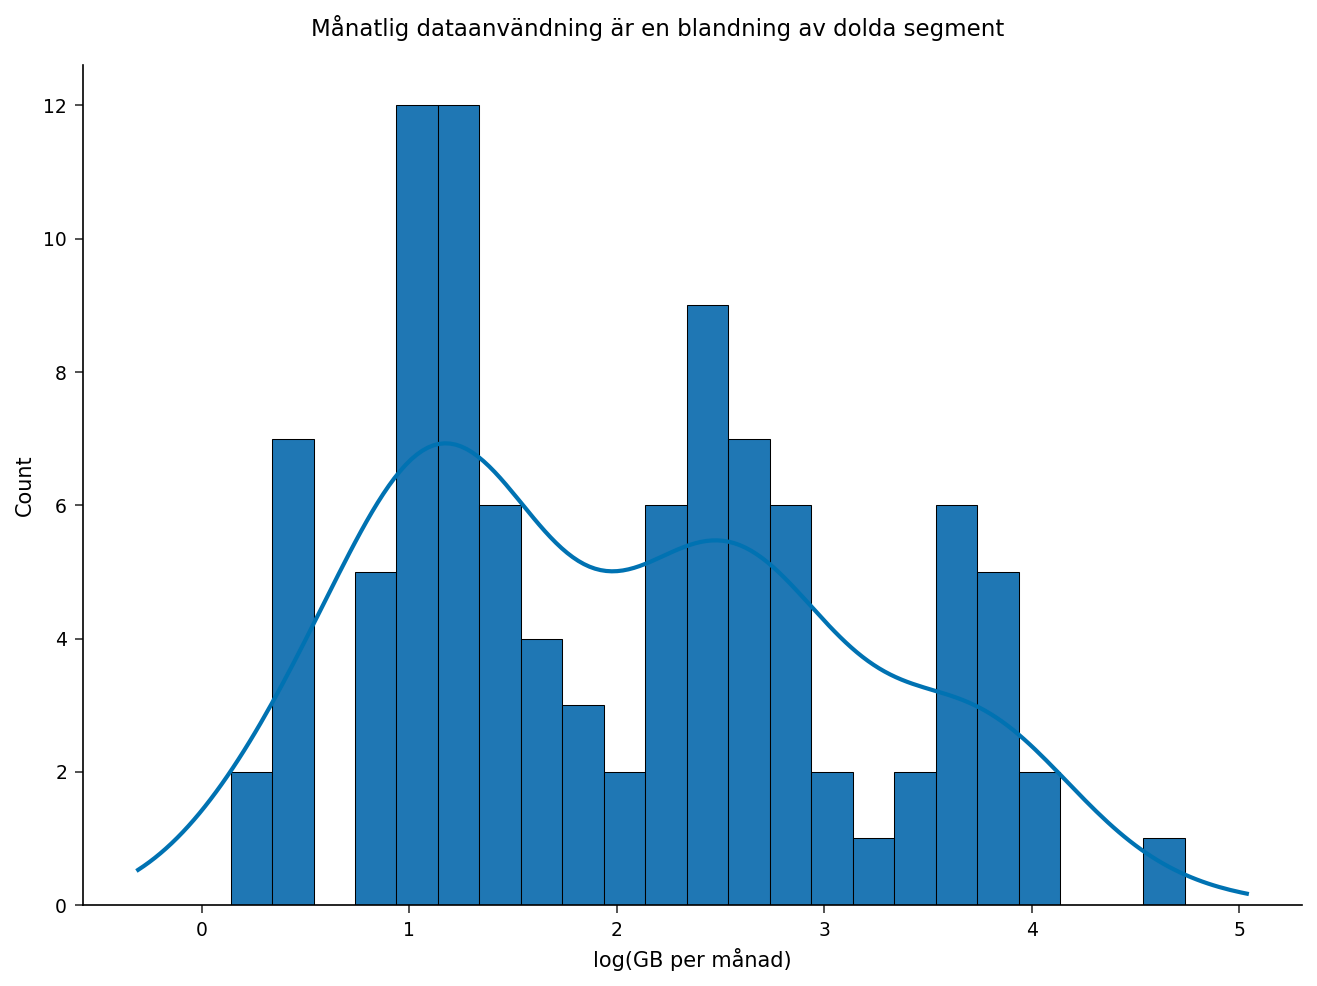

In [2]:
PROCEDUR MEDELVÄRDEN data=subs n mean std MIN p50 MAX maxdec=2;
   VARIABEL data_gb log_gb tenure_months;
   ETIKETT data_gb="Data (GB)" log_gb="Log(data, GB)" tenure_months="Kundlängd (månader)";
KÖR;

PROCEDUR SGPLOT data=subs;
   TITEL "Månatlig dataanvändning är en blandning av dolda segment";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ETIKETT="log(GB per månad)";
KÖR;
TITEL;


## Steg 2 — Hur många segment? Jämför två-, tre- och fyrklusterlösningar

Vi vill inte anta tre nivåer — vi låter datat argumentera för ett antal.
FASTCLUS rapporterar en **total R-kvadrat** (andelen total varians som
förklaras av klustermedelvärdena) och en **Pseudo F-statistika** för varje
lösning. Vi anpassar `MAXCLUSTERS=` 2, 3 och 4 på `log_gb` och läser av dessa
kriterier för varje körning.

- `MAXCLUSTERS=` sätter antalet kluster *k*.
- `MAXITER=` begränsar antalet *k*-means-ompositioneringspass.
- `OUT=` skriver ett poängsatt dataset (används i steg 3–5).

In [3]:
TITEL "Tvåsegmentslösning";
PROCEDUR FASTCLUS data=subs maxclusters=2 MAXITER=50 out=c2;
   VARIABEL log_gb;
   ETIKETT log_gb="Log(data, GB)";
KÖR;

TITEL "Tresegmentslösning";
PROCEDUR FASTCLUS data=subs maxclusters=3 MAXITER=50 out=c3;
   VARIABEL log_gb;
   ETIKETT log_gb="Log(data, GB)";
KÖR;

TITEL "Fyrsegmentslösning";
PROCEDUR FASTCLUS data=subs maxclusters=4 MAXITER=50 out=c4;
   VARIABEL log_gb;
   ETIKETT log_gb="Log(data, GB)";
KÖR;
TITEL;


                                                   Tvåsegmentslösning                                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Tvåsegmentslösning.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Tresegmentslösning.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Fyrsegmentslösning.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Vid en jämförelse av de tre körningarna sida vid sida: den **totala
R-kvadraten** klättrar från **0.753** vid två kluster till **0.899** vid tre —
ett stort hopp på +0.146 när den tredje nivån löses upp — och sedan bara till
**0.941** vid fyra. Fyrklusterlösningen köper den lilla vinsten genom att
*dela den lätta nivån i två* (dess två minsta centroider ligger båda inom det
planterade Lätt-intervallet), inte genom att hitta en genuint ny kundtyp. Den
**Pseudo F-statistikan** berättar samma historia: den största strukturella
förbättringen är steget till tre kluster (F = 299 → 431). Tre segment är den
ärliga stoppunkten, och den modell vi går vidare med.

## Steg 3 — Anpassa tresegmentsmodellen och karakterisera varje segment

Vi anpassar om med `MAXCLUSTERS=3` och skriver de poängsatta raderna till
`scored`. `OUT=`-datasetet för automatiskt med sig varje indatakolumn —
inklusive den ursprungliga användningen, kundlängden och den utelämnade
`segment_true` — tillsammans med de nya kolumnerna `CLUSTER` och `DISTANCE`,
så inget separat kopieringssteg behövs. FASTCLUS skriver ut en
**klustersammanfattning** (storlek och spridning inom kluster per segment)
och **klustermedelvärdena** på den klustrade skalan (`log_gb`).

In [4]:
PROCEDUR FASTCLUS data=subs maxclusters=3 MAXITER=50 out=scored;
   VARIABEL log_gb;
   ETIKETT log_gb="Log(data, GB)";
KÖR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


De tre klustermedelvärdena på loggskalan är **1.05**, **2.51** och **3.77**.
Tillbaka på den ursprungliga GB-skalan är det ungefär **exp(1.05) ≈ 2.9 GB**,
**exp(2.51) ≈ 12.3 GB** och **exp(3.77) ≈ 43 GB** — de lätta, medel- och
tunga nivåerna. Klustersammanfattningen storleksbestämmer dem till **49**,
**34** och **17** abonnenter, vilket följer den planterade ~50/35/15-delningen.
Nästa steg läser samma segment igen i vanliga GB-termer.

## Steg 4 — Poängsätt och karakterisera segment i affärstermer

Datasetet `OUT=scored` för med sig varje abonnents `CLUSTER` (hård
segmentetikett) och `DISTANCE` (euklidiskt avstånd från dess klustercentroid
på loggskalan — litet betyder en säker, central tilldelning). Vi
sammanfattar de upptäckta segmenten efter deras faktiska GB-användning och
kundlängd, och listar sedan några poängsatta rader.

In [5]:
PROCEDUR MEDELVÄRDEN data=scored n mean std MIN MAX maxdec=2;
   KLASS CLUSTER;
   VARIABEL data_gb tenure_months distance;
   ETIKETT CLUSTER="Kluster" data_gb="Data (GB)" tenure_months="Kundlängd (månader)" distance="Avstånd";
KÖR;

PROCEDUR SKRIV data=scored(obs=8) noobs;
   VARIABEL subscriber_id data_gb log_gb segment_true CLUSTER distance;
   ETIKETT subscriber_id="Abonnent-ID" data_gb="Data (GB)" log_gb="Log(data, GB)"
         segment_true="Verkligt segment" CLUSTER="Kluster" distance="Avstånd";
KÖR;


                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Data (GB)

        Kluster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                Analysis Variable : tenure_months Kundlängd (månader)

        Kluster           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


På den ursprungliga GB-skalan har de tre segmenten i genomsnitt **3.1 GB**,
**12.8 GB** och **45.4 GB** i månatlig användning — en spridning på en
storleksordning från lätta surfare till tunga streamers. Kolumnen `DISTANCE`
ger ett förtroendemått per abonnent: de utskrivna raderna visar tätt tilldelade
kunder (avstånd nära 0.01–0.06) tillsammans med en mer gränsfallsartad lätt
användare längre från sin centroid — exakt den signal ett lojalitetsteam
skulle använda för att skilja säkra mål från fall som bör granskas närmare.

## Steg 5 — Återvann vi de verkliga nivåerna, och skiftar mixen med kundlängden?

Två sista kontroller. Först korstabellerar vi det upptäckta `CLUSTER` mot den
utelämnade `segment_true` för att se hur troget den oövervakade anpassningen
återvann de planterade nivåerna. Sedan jämför vi genomsnittlig kundlängd över
de upptäckta segmenten — generatorn lutade tyngre användare mot längre
kundlängd, så en verklig segmentering bör återspegla det.

                                      Upptäckt segment mot utelämnad verklig nivå                                       

                                                   The FREQ Procedure

Table of Kluster by Verkligt segment

Kluster |      Lätt |     Medel |      Tung |      Total
--------+-----------+-----------+-----------+-----------
1       |        49 |         0 |         0 |         49
--------+-----------+-----------+-----------+-----------
2       |         2 |        31 |         1 |         34
--------+-----------+-----------+-----------+-----------
3       |         0 |         1 |        16 |         17
--------+-----------+-----------+-----------+-----------
Total   |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


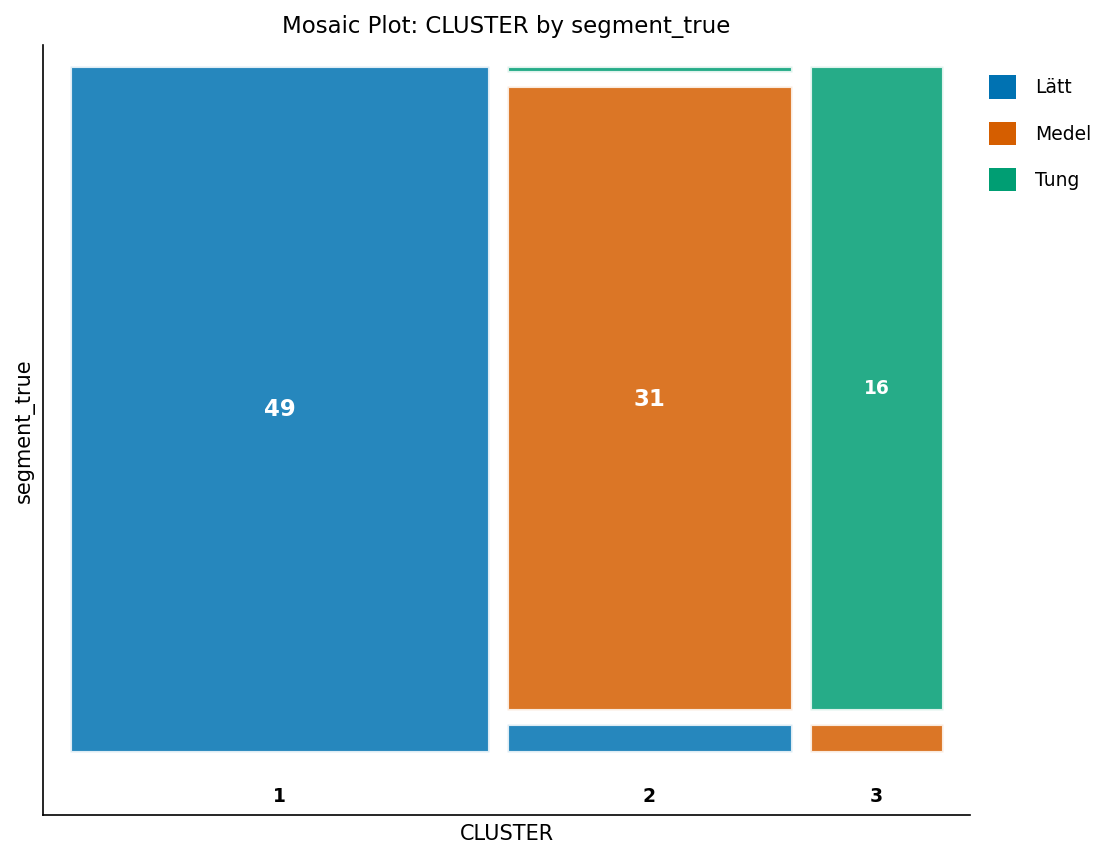

In [6]:
PROCEDUR FREKVENSER data=scored;
   TITEL "Upptäckt segment mot utelämnad verklig nivå";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ETIKETT CLUSTER="Kluster" segment_true="Verkligt segment";
KÖR;
TITEL;


## Tolkning av resultaten

**Vad FASTCLUS hittade.** Med utgångspunkt i en enda högerskev
användningskolumn utan etiketter förklarade tresegments-*k*-means-lösningen
**89.9%** av variansen i logg-användning (total R² = 0.899, Pseudo F = 431)
och delade abonnenter i ett **lätt** segment (medel 3.1 GB, n = 49), ett
**medel**-segment (medel 12.8 GB, n = 34) och ett **tungt** segment (medel
45.4 GB, n = 17). Korstabelleringen mot den utelämnade `segment_true`
återvann den planterade strukturen nästan exakt — **96 av 100** abonnenter
hamnade i klustret som matchade deras genererande nivå (Lätt 49/49, Medel
31/34, Tung 16/17).

**Varför loggskalan.** Dataanvändning är strikt positiv och tungsvansad;
att klustra `log_gb` håller euklidiska avstånd meningsfulla och
segmentmedelvärdena väl separerade, medan den exponentiella
återtransformationen återskapar den realistiska skevheten på GB-skalan.

**Varför detta spelar roll operativt.** Varje abonnent lämnar modellen med
en hård segmentetikett *och* ett avstånd-till-centroid-mått, så att
operatören kan agera med kalibrerad säkerhet — säkert rikta centrala tunga
användare mot premiumabonnemang och flagga gränsfallskunder (stort avstånd)
för närmare granskning. Genomsnittlig kundlängd skiljer sig också mellan de
upptäckta segmenten, en ingång för livscykel- och uppsäljningstiming.

**Att välja antalet segment.** Att jämföra `MAXCLUSTERS=` 2, 3 och 4 på
total R² och Pseudo F är ett transparent, reproducerbart sätt att välja *k*:
den stora vinsten vid tre kluster och den bara kosmetiska vinsten vid fyra
(som delar den lätta nivån) gjorde tre till det försvarbara valet här.

**Förhållande till finita blandningsmodeller.** En finit blandningsmodell
(PROC HPFMM / PROC FMM) skulle lägga till mjuka posteriora tillhörigheter och
ett sannolikhetsbaserat BIC för antalet komponenter. Dessa procedurer är
ännu inte numeriskt implementerade i den här versionen; PROC FASTCLUS
levererar samma handlingsbara segmentering — upptäckt, karakterisering, hård
tilldelning och ett förtroendemått — med fullt numerisk, reproducerbar utdata
idag.